# The Beginning

Hopefully I will be using this file to create a script to find the carrier concentration of a specific metal and eventually implement a doping mechanic. I don't know what these mean yet, but I should be the end!

In [1]:
import numpy as np
from scipy.integrate import quad
import physics_tools as pt
import matplotlib.pyplot as plt
# Fundamental Constants
k_B = 1.3806e-23 # Boltzmann
h_bar = 1.0545e-34 # Reduced Planck
m_e = 9.109e-31 # electron mass
q = 1.602e-19 # electron charge

# Silicon constants for testing
m_eff = 1.08 * m_e # effective mass
E_gap = 1.12 * q # Bandgap energy
E_Fermi = 0.56 * q # Fermi level


In [2]:
def fermi_dirac_dist(E, E_F, T):      #
    exponent = (E - E_F) / (k_B * T)  # Fermi-Dirac distribution
    return 1 / (1 + np.exp(exponent)) #

def density_states(E, E_c):    #
    prefactor = (1 / (2 * np.pi**2)) * (2 * m_eff / h_bar**2)**1.5
    #g = np.where(E>=E_c, prefactor * np.sqrt(E-E_c), 0)
    g = prefactor * np.sqrt(np.maximum(0, E - E_c))
    return g

def integrand(E, E_c, E_F, T):                                  #
    return density_states(E, E_c) * fermi_dirac_dist(E, E_F, T) # Fermi-Dirac integral

In [3]:
# Testing Parameters
Temp = 300
E_conduction = 1.12 * q

n_true, error = quad(integrand, E_conduction, E_conduction + (10 * k_B * Temp),args=(E_conduction, E_Fermi, Temp))
n = pt.simpson_vector(integrand, E_conduction, E_conduction + (10 * k_B * Temp), 1000, E_conduction, E_Fermi, Temp)
err = np.abs((n - n_true)/n_true)*100
print(f"Carrier concentration (n) at {Temp}K: {n} m^-3")
print(f"Carrier concentration (n_true) at {Temp}K: {n_true} m^-3")
print(f"Error for n against n_true: {err}%")

Carrier concentration (n) at 300K: 1.1034421659959098e+16 m^-3
Carrier concentration (n_true) at 300K: 1.103543452083969e+16 m^-3
Error for n against n_true: 0.009178260073758573%


$$f(E)=\frac{1}{1+e^{\frac{E-E_F}{k_BT}}}$$This is the Fermi-Dirac Distribution function $$g(E) = \frac{1}{2\pi^2} \left(\frac{2m_3^*}{\hbar^2}\right)^{3/2}\sqrt{E-E_c}$$This is the Density of States function

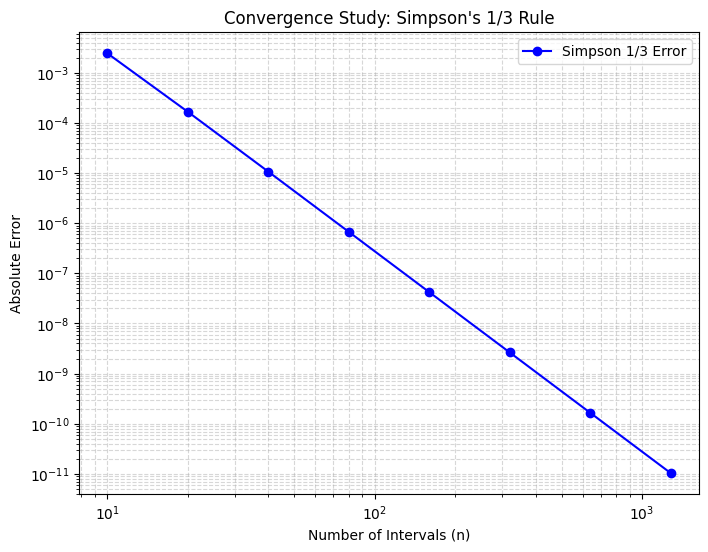

In [4]:

# 1. Define a "Physics-like" test function
def test_func(x, decay_rate):
    return np.exp(-decay_rate * x)

# 2. Define the exact analytical answer so we can calculate the error
# Integral of e^(-2x) from 0 to 5 is: (1/2) * (1 - e^(-10))
decay_rate = 2
a, b = 0, 5
exact_area = (1 / decay_rate) * (1 - np.exp(-decay_rate * b))

# 3. Create an array of n values to test (MUST be even numbers!)
n_values = np.array([10, 20, 40, 80, 160, 320, 640, 1280])
errors = []

# 4. Run the simulation for each step size
for n in n_values:
    # Remember to pass your 'decay_rate' *args at the end!
    sim_area = pt.simpson_vector(test_func, a, b, n, decay_rate)

    # Calculate Absolute Error
    err = abs(exact_area - sim_area)
    errors.append(err)

# 5. Plotting the Error
plt.figure(figsize=(8, 6))
plt.loglog(n_values, errors, marker='o', linestyle='-', color='blue', label='Simpson 1/3 Error')

# Formatting for a professional look
plt.xlabel('Number of Intervals (n)')
plt.ylabel('Absolute Error')
plt.title('Convergence Study: Simpson\'s 1/3 Rule')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

The %error between my custom simpson_vector function and SciPy's quad function at 1000 iterations is roughly 0.01% meaning it should be currently able to be used in "production"

In [11]:


def safe_fermi_dirac(E, Ef, T):
    # Prevent Division by Zero if T is exactly 0
    if T <= 0:
        return np.where(E < Ef, 1.0, 0.0)

    exponent = (E - Ef) / (k_B * T)

    # If the exponent is huge (e.g., > 700), the probability is 0
    # If the exponent is very small (e.g., < -700), the probability is 1
    return np.where(exponent > 700, 0.0,
           np.where(exponent < -700, 1.0,
           1 / (1 + np.exp(exponent))))

E = np.linspace(E_conduction -(0.2 * q),E_conduction + (10 * k_B * Temp), 100)
y_left = density_states(E, E_conduction)
y_right = safe_fermi_dirac(E, E_conduction, Temp)

T_range = np.linspace(200, 600, 50)
#n_values = [quad(integrand, E_conduction, E_conduction + (10 * k_B * Temp),args=(E_conduction, E_Fermi, Temp))[0] for Temp in T_range]
n_values = [pt.simpson_vector(integrand, E_conduction, E_conduction + (10 * k_B * Temp), 1000, E_conduction, E_Fermi, Temp) for Temp in T_range]

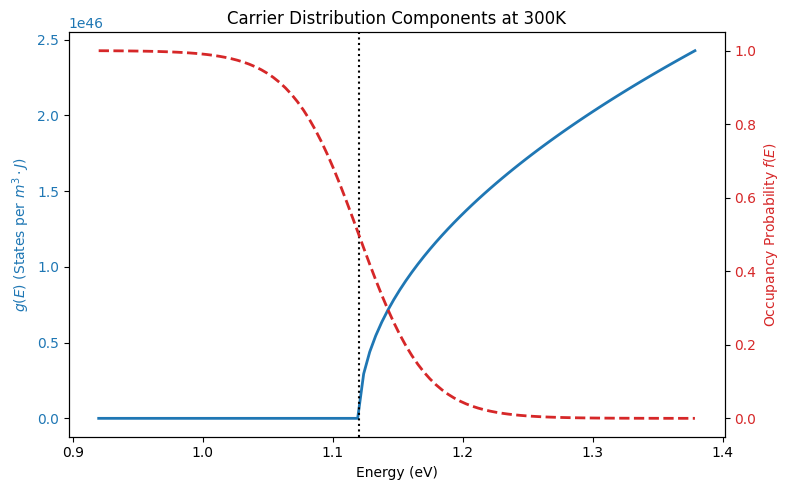

In [12]:
'''
fig, ax1 = plt.subplots()
ax1.plot(E, y_left)
ax1.set_ylabel("g(E)")

ax2 = ax1.twinx()
ax2.plot(E, y_right)
ax2.set_ylabel("f(E)")
'''
# Convert Energy array to eV for the x-axis ONLY
E_ev = E / q

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Density of States (Left Axis)
color1 = 'tab:blue'
ax1.plot(E_ev, y_left, color=color1, linewidth=2, label='Density of States')
ax1.set_xlabel('Energy (eV)')
ax1.set_ylabel(r'$g(E)$ (States per $m^3 \cdot J$)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create the second axis for Probability
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(E_ev, y_right, color=color2, linestyle='--', linewidth=2, label='Fermi-Dirac')
ax2.set_ylabel('Occupancy Probability $f(E)$', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add a vertical line to show where the Conduction Band starts
ax1.axvline(E_conduction/q, color='black', linestyle=':', label='$E_c$')

plt.title(f'Carrier Distribution Components at {Temp}K')
fig.tight_layout()
plt.show()

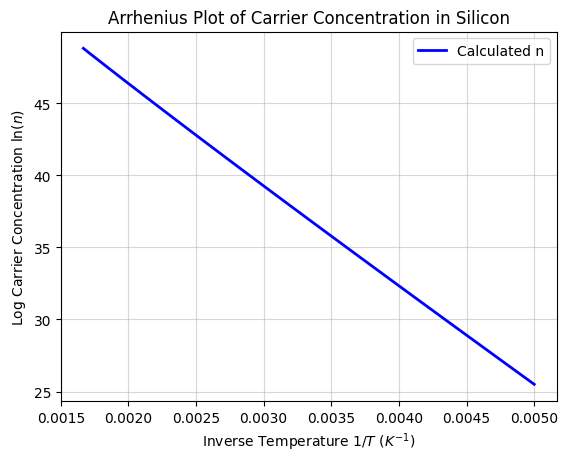

In [13]:
plt.plot(1/T_range, np.log(n_values), label='Calculated n', color='blue', linewidth=2)

plt.xlabel(r'Inverse Temperature $1/T$ ($K^{-1}$)')
plt.ylabel(r'Log Carrier Concentration $\ln(n)$')
plt.title('Arrhenius Plot of Carrier Concentration in Silicon')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

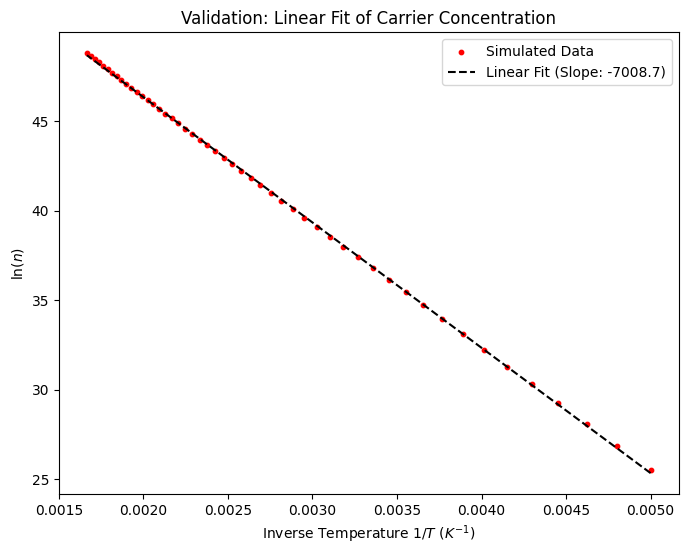

Linear Fit: y = -7008.68x + 60.37


In [14]:
# 1. Get the slope and intercept
m, b = np.polyfit(1/T_range, np.log(n_values), 1)

# 2. Create the "Fit" line
fit_line = m * (1/T_range) + b

# 3. Plot both
plt.figure(figsize=(8, 6))
plt.scatter(1/T_range, np.log(n_values), label='Simulated Data', color='red', s=10)
plt.plot(1/T_range, fit_line, label=f'Linear Fit (Slope: {m:.1f})', color='black', linestyle='--')

plt.xlabel(r'Inverse Temperature $1/T$ ($K^{-1}$)')
plt.ylabel(r'$\ln(n)$')
plt.legend()
plt.title('Validation: Linear Fit of Carrier Concentration')
plt.show()

print(f'Linear Fit: y = {m:.2f}x + {b:.2f}')

Now that we have the slope $m = -7008.68$ eV, we can find the "real" Silicon bandgap with $$m=-\frac{E_g}{2K_B}$$ this simplifies to $$E_g = m\cdot (-2\cdot k_B)$$ using the eV Boltzmann constant ($k_B = 8.617\times 10^{-5}$) $$E_g = -7008.68\cdot(-2\cdot 8.617\times 10^{-5}) \approx 1.208 \text{ eV}$$This fits the widely accepted value of the effective bandgap $E_{eff} = 1.21$ eV

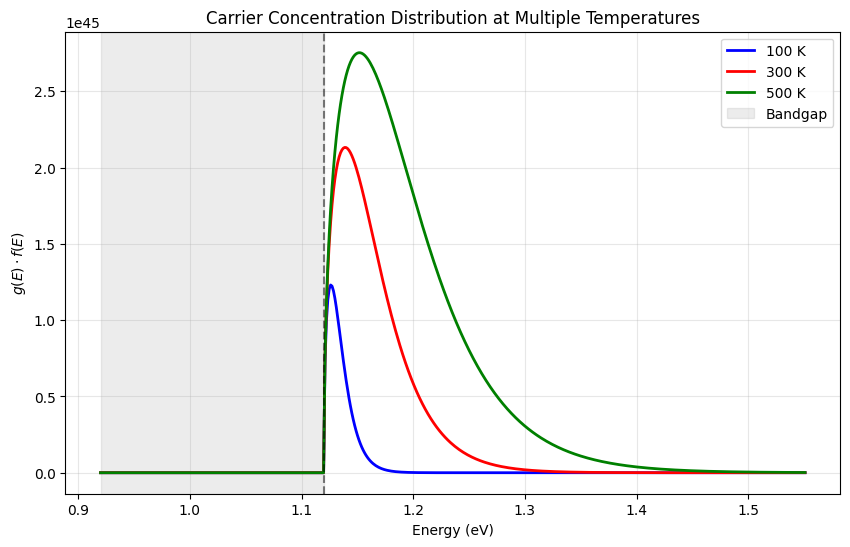

In [15]:
E_unified = np.linspace(E_conduction -(.2* q) ,E_conduction + (10 * k_B * 500), 500)

y_100 = safe_fermi_dirac(E_unified, E_conduction, 100)*density_states(E_unified, E_conduction)
y_300 = safe_fermi_dirac(E_unified, E_conduction, 300)*density_states(E_unified, E_conduction)
y_500 = safe_fermi_dirac(E_unified, E_conduction, 500)*density_states(E_unified, E_conduction)

plt.figure(figsize=(10, 6))

plt.plot(E_unified/q, y_100, label='100 K', color='blue', lw=2)
plt.plot(E_unified/q, y_300, label='300 K', color='red', lw=2)
plt.plot(E_unified/q, y_500, label='500 K', color='green', lw=2)

plt.axvspan(E_unified[0]/q, E_conduction/q, color='gray', alpha=0.15, label='Bandgap')
plt.axvline(E_conduction/q, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Energy (eV)')
plt.ylabel(r'$g(E) \cdot f(E)$')
plt.title('Carrier Concentration Distribution at Multiple Temperatures')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()